<a href="https://colab.research.google.com/github/Heineeee/ML-2026-1R/blob/SJ/Preprocess_Pretrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import zipfile
import os

MYDRIVE = Path("/content/drive/MyDrive")

BASE_DIR = MYDRIVE / "VTaC_Project"
PRETRAIN_DIR = BASE_DIR / "vt_ecg_pretrain"

CUDB_RAW = PRETRAIN_DIR / "cudb" / "raw"
VFDB_RAW = PRETRAIN_DIR / "vfdb" / "raw"
WINDOW_DIR = PRETRAIN_DIR / "windows"
CKPT_DIR = PRETRAIN_DIR / "checkpoints"

for d in [CUDB_RAW, VFDB_RAW, WINDOW_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def find_zip_by_keyword(root, keywords):
    zips = list(Path(root).glob("*.zip"))
    for z in zips:
        name = z.name.lower()
        if all(k.lower() in name for k in keywords):
            return z
    return None

CUDB_ZIP = find_zip_by_keyword(MYDRIVE, ["cudb"])
VFDB_ZIP = find_zip_by_keyword(MYDRIVE, ["vfdb"])

print("CUDB_ZIP:", CUDB_ZIP)
print("VFDB_ZIP:", VFDB_ZIP)

def unzip_if_needed(zip_path, out_dir):
    if zip_path is None:
        print(f"zip not found for {out_dir}")
        return

    marker = out_dir / ".unzipped"

    if marker.exists():
        print(f"already unzipped: {out_dir}")
        return

    print(f"unzipping {zip_path} -> {out_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

    marker.touch()
    print("done:", out_dir)

unzip_if_needed(CUDB_ZIP, CUDB_RAW)
unzip_if_needed(VFDB_ZIP, VFDB_RAW)

Mounted at /content/drive
CUDB_ZIP: /content/drive/MyDrive/cudb.zip
VFDB_ZIP: /content/drive/MyDrive/vfdb.zip
already unzipped: /content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw
already unzipped: /content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/vfdb/raw


In [3]:
print("CUDB files")
for p in list(CUDB_RAW.rglob("*"))[:20]:
    print(p)

print("\nVFDB files")
for p in list(VFDB_RAW.rglob("*"))[:20]:
    print(p)

CUDB files
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/.unzipped
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu04.hea
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu20.hea-
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu24.xws
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu27.dat
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu28.xws
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu10.dat
/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu26.he

In [4]:
!pip -q install wfdb pywavelets scipy

from pathlib import Path

def find_record_names(root):
    hea_files = list(Path(root).rglob("*.hea"))
    records = sorted(list(set(str(p.with_suffix("")) for p in hea_files)))
    return records

cudb_records = find_record_names(CUDB_RAW)
vfdb_records = find_record_names(VFDB_RAW)

print("CUDB records:", len(cudb_records))
print("VFDB records:", len(vfdb_records))
print("CUDB example:", cudb_records[:3])
print("VFDB example:", vfdb_records[:3])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 146.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
CUDB records: 35
VFDB records: 22
CUDB example: ['/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/

In [5]:
PRETRAIN_DATA_PATH = WINDOW_DIR / "cudb_vfdb_ecg1ch_10s_250hz_pretrain.pt"

In [6]:
ECG_PRETRAIN_CKPT = CKPT_DIR / "ecg_encoder_cudb_vfdb_pretrain.pt"

In [7]:
import wfdb
import numpy as np
import torch
from scipy.signal import resample_poly
from tqdm.auto import tqdm
from math import gcd
import json
import random

TARGET_FS = 250
WIN_SEC = 10
STRIDE_SEC = 2

WIN_LEN = TARGET_FS * WIN_SEC      # 2500
STRIDE = TARGET_FS * STRIDE_SEC    # 500

VT_RHYTHM_KEYS = ["VT", "VFL", "VF", "VFIB"]

def robust_zscore(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad

    if scale < eps:
        scale = np.std(x) + eps

    x = (x - med) / scale
    x = np.clip(x, -8.0, 8.0)
    return x.astype(np.float32)

def resample_to_target(sig, fs, target_fs=250):
    fs_i = int(round(fs))
    target_i = int(round(target_fs))

    if fs_i == target_i:
        return sig.astype(np.float32)

    g = gcd(fs_i, target_i)
    up = target_i // g
    down = fs_i // g

    return resample_poly(sig, up, down).astype(np.float32)

def read_wfdb_signal(record_path):
    rec = wfdb.rdrecord(record_path)
    sig = rec.p_signal

    if sig is None:
        sig = rec.d_signal.astype(np.float32)

    sig = np.asarray(sig, dtype=np.float32)
    fs = float(rec.fs)

    sig_names = getattr(rec, "sig_name", None)
    return sig, fs, sig_names

def get_rhythm_intervals(record_path):
    """
    WFDB .atr aux_note에서 rhythm interval 추출.
    VFDB는 rhythm annotation 중심.
    CUDB도 aux_note가 있으면 사용.
    """
    try:
        ann = wfdb.rdann(record_path, "atr")
    except Exception:
        return []

    samples = np.asarray(ann.sample)
    aux = getattr(ann, "aux_note", None)

    if aux is None:
        return []

    intervals = []
    current_label = None
    current_start = None

    for i, note in enumerate(aux):
        if note is None:
            continue

        note = str(note).strip()

        # rhythm annotation example: "(VT", "(N", "(VFIB"
        if note.startswith("("):
            label = note.replace("(", "").strip()

            if current_label is not None and current_start is not None:
                intervals.append((int(current_start), int(samples[i]), current_label))

            current_label = label
            current_start = int(samples[i])

    return intervals

def is_vt_label(label):
    lab = str(label).upper()
    return any(k in lab for k in VT_RHYTHM_KEYS)

def has_vt_overlap(start, end, vt_intervals, min_overlap_ratio=0.3):
    win_len = end - start

    for s, e, label in vt_intervals:
        if not is_vt_label(label):
            continue

        inter = max(0, min(end, e) - max(start, s))
        if inter / max(win_len, 1) >= min_overlap_ratio:
            return True

    return False

def valid_channel(x, min_std=1e-4):
    x = np.asarray(x)
    if np.isnan(x).all():
        return False
    return np.nanstd(x) > min_std

In [8]:
from sklearn.model_selection import train_test_split

all_records = [(r, "cudb") for r in cudb_records] + [(r, "vfdb") for r in vfdb_records]

train_records, val_records = train_test_split(
    all_records,
    test_size=0.15,
    random_state=42,
    shuffle=True,
)

print("train records:", len(train_records))
print("val records:", len(val_records))
print("val examples:", val_records[:5])

train records: 48
val records: 9
val examples: [('/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu01', 'cudb'), ('/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu06', 'cudb'), ('/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu31', 'cudb'), ('/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu14', 'cudb'), ('/content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/cudb/raw/cu-ventricular-tachyarrhythmia-database-1.0.0/cu35', 'cudb')]


In [9]:
def make_windows_from_record_list(
    record_list,
    max_windows_per_record=600,
    use_vt_regions_if_available=True,
):
    X_list = []
    meta = []

    for rec_path, dataset_name in tqdm(record_list, desc="making ECG windows"):
        try:
            sig, fs, sig_names = read_wfdb_signal(rec_path)
        except Exception as e:
            print("[READ FAIL]", rec_path, e)
            continue

        if sig.ndim == 1:
            sig = sig[:, None]

        original_fs = fs

        # rhythm intervals 원래 fs 기준
        intervals_raw = get_rhythm_intervals(rec_path)

        # target fs 기준으로 변환
        vt_intervals = []
        for s, e, lab in intervals_raw:
            s2 = int(round(s * TARGET_FS / original_fs))
            e2 = int(round(e * TARGET_FS / original_fs))
            vt_intervals.append((s2, e2, lab))

        num_channels = sig.shape[1]

        for ch in range(num_channels):
            x = sig[:, ch]

            if not valid_channel(x):
                continue

            x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
            x = resample_to_target(x, original_fs, TARGET_FS)
            x = robust_zscore(x)

            T = len(x)
            if T < WIN_LEN:
                continue

            starts = list(range(0, T - WIN_LEN + 1, STRIDE))

            selected = []

            if use_vt_regions_if_available and len(vt_intervals) > 0:
                for st in starts:
                    ed = st + WIN_LEN
                    if has_vt_overlap(st, ed, vt_intervals, min_overlap_ratio=0.3):
                        selected.append(st)

            # fallback: annotation이 없거나 VT window가 없으면 전체에서 사용
            if len(selected) == 0:
                selected = starts

            if max_windows_per_record is not None and len(selected) > max_windows_per_record:
                selected = sorted(np.random.choice(selected, size=max_windows_per_record, replace=False).tolist())

            ch_name = sig_names[ch] if sig_names is not None and ch < len(sig_names) else f"ch{ch}"

            for st in selected:
                ed = st + WIN_LEN
                win = x[st:ed]

                X_list.append(win[None, :].astype(np.float32))  # [1, T]
                meta.append({
                    "dataset": dataset_name,
                    "record": rec_path,
                    "channel_index": int(ch),
                    "channel_name": str(ch_name),
                    "start": int(st),
                    "end": int(ed),
                    "fs": TARGET_FS,
                })

    if len(X_list) == 0:
        X = np.zeros((0, 1, WIN_LEN), dtype=np.float32)
    else:
        X = np.stack(X_list, axis=0).astype(np.float32)

    return X, meta

In [10]:
np.random.seed(42)
random.seed(42)

X_train, meta_train = make_windows_from_record_list(
    train_records,
    max_windows_per_record=600,
    use_vt_regions_if_available=True,
)

X_val, meta_val = make_windows_from_record_list(
    val_records,
    max_windows_per_record=600,
    use_vt_regions_if_available=True,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("train meta:", len(meta_train))
print("val meta:", len(meta_val))

making ECG windows:   0%|          | 0/48 [00:00<?, ?it/s]

making ECG windows:   0%|          | 0/9 [00:00<?, ?it/s]

X_train: (15451, 1, 2500)
X_val: (3002, 1, 2500)
train meta: 15451
val meta: 3002


In [11]:
save_path = WINDOW_DIR / "cudb_vfdb_ecg1ch_10s_250hz_pretrain_recordsplit.pt"

torch.save(
    {
        "X_train": torch.from_numpy(X_train),
        "X_val": torch.from_numpy(X_val),
        "meta_train": meta_train,
        "meta_val": meta_val,
        "fs": TARGET_FS,
        "win_sec": WIN_SEC,
        "win_len": WIN_LEN,
        "stride_sec": STRIDE_SEC,
        "channels": 1,
        "split": "record-level",
        "description": "CUDB+VFDB 1-channel ECG windows for VT-specific ECG encoder pretraining",
    },
    save_path,
)

print("saved:", save_path)

saved: /content/drive/MyDrive/VTaC_Project/vt_ecg_pretrain/windows/cudb_vfdb_ecg1ch_10s_250hz_pretrain_recordsplit.pt


In [12]:
data = torch.load(save_path, map_location="cpu", weights_only=False)

print(data.keys())
print("X_train:", data["X_train"].shape)
print("X_val:", data["X_val"].shape)
print("fs:", data["fs"])
print("win_sec:", data["win_sec"])

dict_keys(['X_train', 'X_val', 'meta_train', 'meta_val', 'fs', 'win_sec', 'win_len', 'stride_sec', 'channels', 'split', 'description'])
X_train: torch.Size([15451, 1, 2500])
X_val: torch.Size([3002, 1, 2500])
fs: 250
win_sec: 10


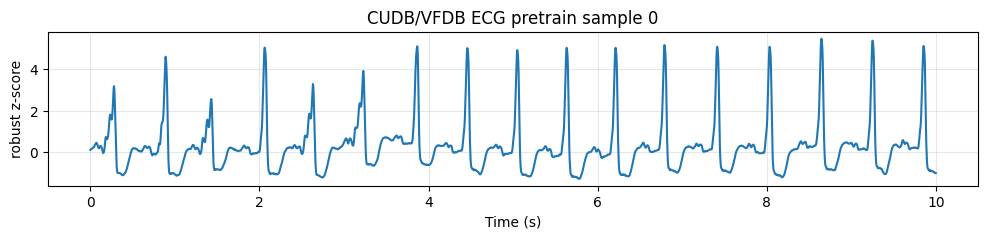

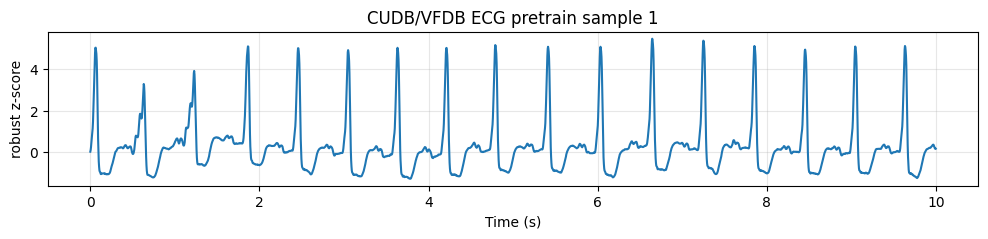

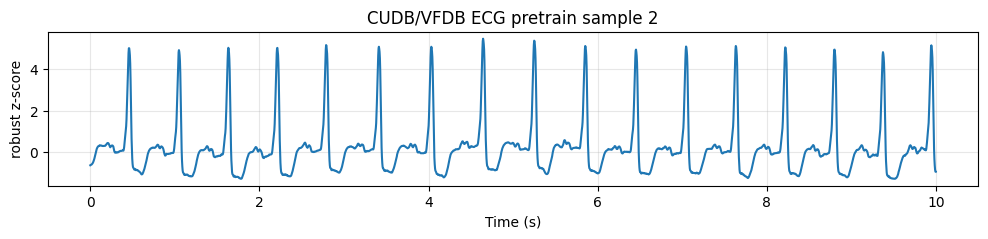

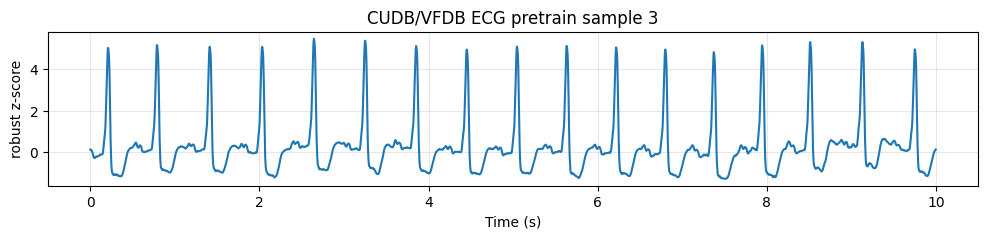

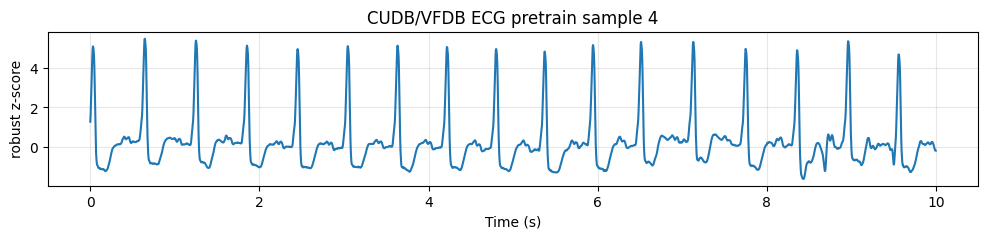

In [13]:
import matplotlib.pyplot as plt

X = data["X_train"]

n_show = min(5, len(X))

for i in range(n_show):
    x = X[i, 0].numpy()
    t = np.arange(len(x)) / data["fs"]

    plt.figure(figsize=(12, 2))
    plt.plot(t, x)
    plt.title(f"CUDB/VFDB ECG pretrain sample {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("robust z-score")
    plt.grid(alpha=0.3)
    plt.show()